In [1]:
print("ambajr")

ambajr


In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
dist_min= np.load (r"D:\PENTING KUYLAH\output\1\dist.npy")
earth_pos=np.load(r"D:\PENTING KUYLAH\output\1\earth_pos.npy")
moon_pos=np.load(r"D:\PENTING KUYLAH\output\1\moon_pos.npy")

In [4]:
earth_min=np.zeros((dist_min.shape[1],2))
moon_min=np.zeros((dist_min.shape[1],2))
for i in range(dist_min.shape[1]):
    earth_min[i,0]=np.min(dist_min[:,i,1])
    earth_min[i,1]=np.argmin(dist_min[:,i,1])

    moon_min[i,0]=np.min(dist_min[:,i,2])
    moon_min[i,1]=np.argmin(dist_min[:,i,2])

In [5]:

print(dist_min.shape)
print(earth_pos.shape)
print(moon_pos.shape)
print(earth_min.shape)
print(moon_min.shape)

(87661, 2000, 3)
(87661, 3)
(87661, 3)
(2000, 2)
(2000, 2)


In [6]:
earth_min_t = np.unique(earth_min[:, 1])
print(earth_min_t)

[69438. 69439. 69440. 69441. 69442. 69443. 69444.]


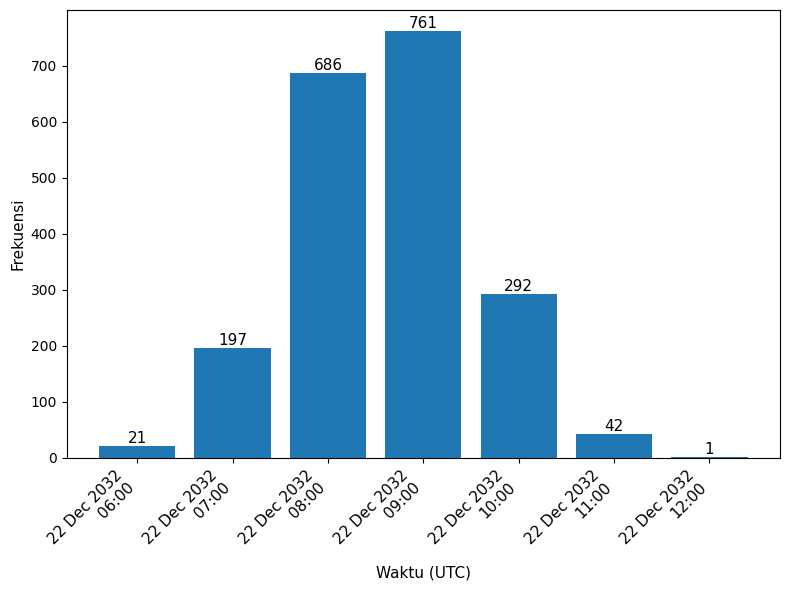

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

kolom2 = np.round(earth_min[:, 1], 0)
nilai, jumlah = np.unique(kolom2, return_counts=True)

# waktu awal
t0 = datetime(2025, 1, 20, 0, 0)

# konversi jam → datetime
waktu_datetime = [t0 + timedelta(hours=int(jam)) for jam in nilai]

# format label (tanggal tetap ada)
label_waktu = [dt.strftime("%d %b %Y\n%H:%M") for dt in waktu_datetime]

plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(nilai)), jumlah)

plt.xlabel("Waktu (UTC)",fontsize=11)
plt.ylabel("Frekuensi",fontsize=11)


# pakai label waktu di sumbu X
plt.xticks(range(len(nilai)), label_waktu, rotation=45, ha="right",fontsize=11)

# angka di atas batang
for bar in bars:
    tinggi = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        tinggi,
        f"{int(tinggi)}",
        ha="center",
        va="bottom",
        fontsize=11
    )
plt.savefig('Persebaran waktu_1.png', dpi=600,bbox_inches='tight')
plt.tight_layout()
plt.show()


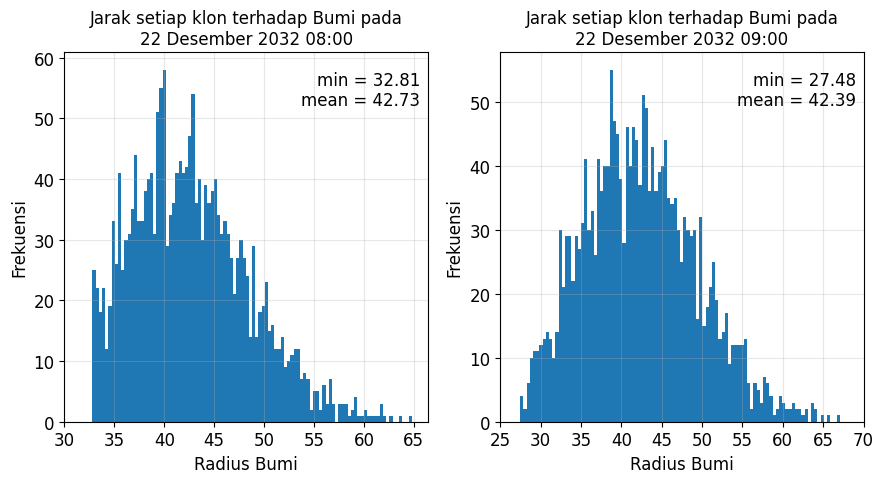

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# samakan ukuran font semua elemen
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# daftar timestep & judul waktu
timesteps = [69440, 69441]
titles = [
    "22 Desember 2032 08:00",
    "22 Desember 2032 09:00"
]

# konversi AU ke Radius Bumi
R_earth_per_AU = 149_597_870 / 6_371

fig, axes = plt.subplots(1, 2, figsize=(9,5))

for idx, ts in enumerate(timesteps):

    # ambil jarak klon terhadap bumi
    earth_r = dist_min[ts, :, 1]
    nilai_R_earth = earth_r * R_earth_per_AU

    # statistik
    nilai_min = np.min(nilai_R_earth)
    nilai_mean = np.mean(nilai_R_earth)

    # histogram
    axes[idx].hist(nilai_R_earth, bins=100)

    # teks statistik
    axes[idx].text(
        0.98, 0.95,
        f"min = {nilai_min:.2f}\nmean = {nilai_mean:.2f}",
        transform=axes[idx].transAxes,
        ha="right",
        va="top",
        fontsize=12
    )

    # tick tiap 5 Radius Bumi
    xmin = np.floor(nilai_R_earth.min() / 5) * 5
    xmax = np.ceil(nilai_R_earth.max() / 5) * 5
    xticks = np.arange(xmin, xmax + 5, 5)

    axes[idx].set_xticks(xticks)

    # label dan judul
    axes[idx].set_xlabel("Radius Bumi")
    axes[idx].set_ylabel("Frekuensi")
    axes[idx].set_title(f"Jarak setiap klon terhadap Bumi pada\n{titles[idx]}")

    # grid tipis
    axes[idx].grid(alpha=0.3)

plt.tight_layout()

plt.savefig("jarak_close_approach_1.png", dpi=600, bbox_inches="tight")

plt.show()